<a href="https://colab.research.google.com/github/Yok3712/First-project-autonomy/blob/main/Filtre_Kalman.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

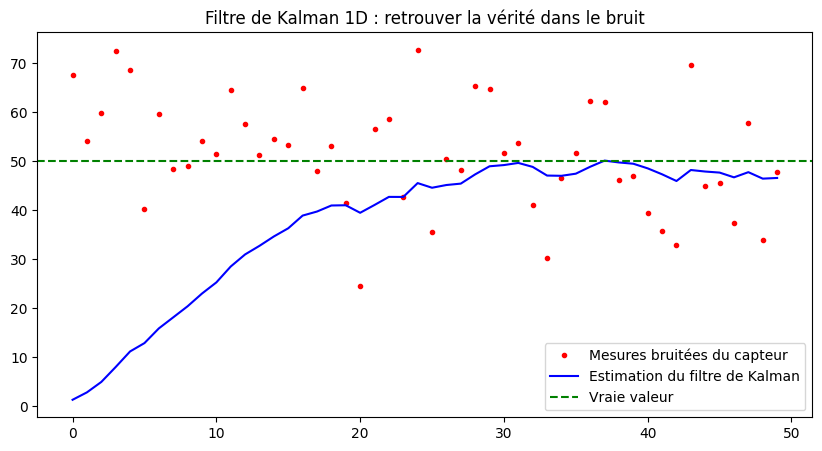

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 1. La VRAIE position (qu'en vrai on ne connaît pas) : un objet à la position 50
vraie_valeur = 50.0
n = 50  # nombre de mesures

# 2. Les MESURES bruitées du capteur (vérité + bruit aléatoire)
np.random.seed(0)  # pour avoir le même hasard à chaque fois
mesures = vraie_valeur + np.random.normal(0, 10, n)

# 3. Le filtre de Kalman (version 1D simplifiée)
estimation = 0.0      # notre estimation de départ (on part ignorant)
incertitude = 1.0     # à quel point on doute de notre estimation
bruit_capteur = 100   # à quel point le capteur est mauvais
estimations = []

for z in mesures:
    # PRÉDICTION : sans info nouvelle, l'incertitude grandit un peu
    incertitude += 1
    # CORRECTION : on combine notre estimation avec la nouvelle mesure z
    K = incertitude / (incertitude + bruit_capteur)  # le "gain de Kalman"
    estimation = estimation + K * (z - estimation)
    incertitude = (1 - K) * incertitude
    estimations.append(estimation)

# 4. On affiche tout
plt.figure(figsize=(10, 5))
plt.plot(mesures, 'r.', label="Mesures bruitées du capteur")
plt.plot(estimations, 'b-', label="Estimation du filtre de Kalman")
plt.axhline(vraie_valeur, color='g', linestyle='--', label="Vraie valeur")
plt.legend()
plt.title("Filtre de Kalman 1D : retrouver la vérité dans le bruit")
plt.show()